In [1]:
# ==== Cell 1: Đọc theo chunks + gom theo giờ ====
import pandas as pd, numpy as np
from pathlib import Path

DATA_PATH = "household_power_consumption.txt"   # sửa nếu cần
CHUNK = 200_000
ENCODING = "utf-8"
USE_COLS = ["Date","Time","Global_active_power","Global_reactive_power","Voltage",
            "Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]

reader = pd.read_csv(
    DATA_PATH, sep=";", engine="python", on_bad_lines="skip",
    usecols=USE_COLS, dtype=str, chunksize=CHUNK, encoding=ENCODING
)

hourly_parts, bad = [], 0
for i, chunk in enumerate(reader, 1):
    dt = pd.to_datetime(chunk["Date"].str.strip()+" "+chunk["Time"].str.strip(),
                        dayfirst=True, errors="coerce")
    chunk = chunk.assign(Datetime=dt).drop(columns=["Date","Time"])
    for c in chunk.columns:
        if c != "Datetime":
            chunk[c] = pd.to_numeric(chunk[c], errors="coerce").astype("float32")
    n_before = len(chunk)
    chunk = chunk.dropna(subset=["Datetime","Global_active_power","Global_reactive_power",
                                 "Voltage","Global_intensity","Sub_metering_1",
                                 "Sub_metering_2","Sub_metering_3"])
    bad += (n_before - len(chunk))
    chunk["Hour"] = chunk["Datetime"].dt.floor("H")
    agg = chunk.groupby("Hour", as_index=True)[
        ["Global_active_power","Global_reactive_power","Voltage",
         "Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]
    ].mean()
    hourly_parts.append(agg)
    if i % 5 == 0: print(f"• Đã xử lý ~{i*CHUNK:,} dòng...")

df_hour = pd.concat(hourly_parts).groupby(level=0).mean().sort_index()
df_hour = df_hour.reset_index().rename(columns={"Hour":"Datetime"})
print("Khoảng thời gian:", df_hour["Datetime"].min(), "→", df_hour["Datetime"].max())
print("Số điểm theo giờ:", len(df_hour), "| Số dòng lỗi/NA bỏ qua:", bad)
df_hour.head()


C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version,

• Đã xử lý ~1,000,000 dòng...


C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")
C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version,

• Đã xử lý ~2,000,000 dòng...
Khoảng thời gian: 2006-12-16 17:00:00 → 2010-11-26 21:00:00
Số điểm theo giờ: 34168 | Số dòng lỗi/NA bỏ qua: 25979


C:\Users\Dell\AppData\Local\Temp\ipykernel_28000\2457558488.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  chunk["Hour"] = chunk["Datetime"].dt.floor("H")


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:00:00,4.222889,0.229000,234.643875,18.099998,0.0,0.527778,16.861111
1,2006-12-16 18:00:00,3.632200,0.080033,234.580154,15.600000,0.0,6.716667,16.866667
2,2006-12-16 19:00:00,3.400233,0.085233,233.232498,14.503333,0.0,1.433333,16.683332
3,2006-12-16 20:00:00,3.268567,0.075100,234.071503,13.916667,0.0,0.000000,16.783333
4,2006-12-16 21:00:00,3.056467,0.076667,237.158661,13.046666,0.0,0.416667,17.216667


In [2]:
# ==== Cell 2: Làm sạch nhẹ ====
clean = df_hour.copy()
clean["Global_active_power"] = clean["Global_active_power"].clip(lower=0)

for c in ["Global_active_power","Global_reactive_power","Voltage",
          "Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]:
    q1, q3 = clean[c].quantile([0.01, 0.99])  # clip 1% & 99% để bỏ đuôi dài
    clean[c] = clean[c].clip(q1, q3)

clean = clean.dropna().reset_index(drop=True)
print("Kích thước sau làm sạch:", clean.shape)


Kích thước sau làm sạch: (34168, 8)


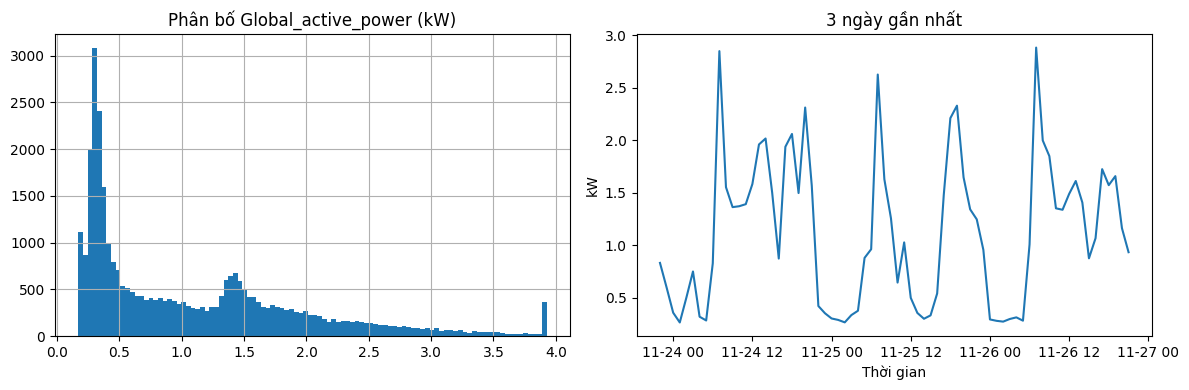

In [3]:
# ==== Cell 3: Trực quan nhanh ====
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(12,4))
clean["Global_active_power"].hist(bins=100, ax=ax[0]); ax[0].set_title("Phân bố Global_active_power (kW)")
N_SHOW = 3*24
ax[1].plot(clean["Datetime"].iloc[-N_SHOW:], clean["Global_active_power"].iloc[-N_SHOW:])
ax[1].set_title("3 ngày gần nhất"); ax[1].set_xlabel("Thời gian"); ax[1].set_ylabel("kW")
plt.tight_layout(); plt.show()


In [4]:
# ==== Cell 4: Feature engineering (time & lags) ====
dt = clean["Datetime"]
df_fe = clean.copy()

# 1) Đặc trưng thời gian cơ bản
df_fe["year"]  = dt.dt.year
df_fe["month"] = dt.dt.month
df_fe["day"]   = dt.dt.day
df_fe["hour"]  = dt.dt.hour
df_fe["dow"]   = dt.dt.dayofweek  # day of week

import numpy as np

# 2) Đặc trưng chu kỳ (cyclical features)
df_fe["sin_hour"] = np.sin(2*np.pi*df_fe["hour"] / 24)
df_fe["cos_hour"] = np.cos(2*np.pi*df_fe["hour"] / 24)
df_fe["sin_dow"]  = np.sin(2*np.pi*df_fe["dow"]  / 7)
df_fe["cos_dow"]  = np.cos(2*np.pi*df_fe["dow"]  / 7)

# 3) Trung bình trượt 24 giờ CHỈ dùng dữ liệu quá khứ
#    => shift(1): tại thời điểm t chỉ dùng thông tin đến t-1
gap_shifted = df_fe["Global_active_power"].shift(1)
df_fe["GAP_mean24"] = gap_shifted.rolling(24, min_periods=1).mean()

# 4) Các đặc trưng trễ (lag) – vẫn giữ nguyên như cũ
for lag in [1, 2, 3, 24]:
    df_fe[f"GAP_lag{lag}"] = df_fe["Global_active_power"].shift(lag)

# 5) Bỏ các dòng bị NaN do shift/rolling
df_fe = df_fe.dropna().reset_index(drop=True)
print("Sau feature engineering:", df_fe.shape)
df_fe.head(3)


Sau feature engineering: (34144, 22)


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,...,dow,sin_hour,cos_hour,sin_dow,cos_dow,GAP_mean24,GAP_lag1,GAP_lag2,GAP_lag3,GAP_lag24
0,2006-12-17 17:00:00,3.406767,0.166633,234.229828,14.509999,0.0,0.466667,16.816668,2006,12,...,6,-0.965926,-2.588190e-01,-0.781831,0.62349,2.486854,3.326033,2.985400,2.092633,3.927904
1,2006-12-17 18:00:00,3.697100,0.135067,234.372330,15.750000,0.0,0.000000,16.833334,2006,12,...,6,-1.000000,-1.836970e-16,-0.781831,0.62349,2.465140,3.406767,3.326033,2.985400,3.632200
2,2006-12-17 19:00:00,2.908400,0.265167,233.195663,12.516666,0.0,0.516667,16.683332,2006,12,...,6,-0.965926,2.588190e-01,-0.781831,0.62349,2.467844,3.697100,3.406767,3.326033,3.400233


In [5]:
# ==== Cell 5: Chia train/test (80/20 theo thời gian) ====
target = "Global_active_power"
X = df_fe.drop(columns=["Datetime", target])
y = df_fe[target]

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
len(X_train), len(X_test)


(27315, 6829)

In [6]:
# ==== Cell 6 (rút gọn & trình bày đẹp): Chọn tối đa 3 mô hình nâng cao ====
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Thử XGBoost (nếu chưa cài, tự bỏ qua)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Chọn mô hình bạn muốn chạy (≤ 3)
USE_MODELS = ["RF", "HGB", "XGB"]   # ví dụ: ["RF","HGB"] nếu chưa cài xgboost

models = {}
if "RF" in USE_MODELS:
    models["RandomForest"] = RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    )
if "HGB" in USE_MODELS:
    models["HistGradientBoosting"] = HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.08, random_state=42
    )
if "XGB" in USE_MODELS:
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=42, tree_method="hist"
        )
    else:
        print("⚠️  Bỏ qua XGBoost: chưa cài gói 'xgboost'.")

# In tóm tắt gọn gàng
def _short_cfg(name, mdl):
    if name == "RandomForest":
        return {
            "n_estimators": mdl.n_estimators, "n_jobs": mdl.n_jobs,
            "random_state": mdl.random_state
        }
    if name == "HistGradientBoosting":
        return {
            "max_iter": mdl.max_iter, "learning_rate": mdl.learning_rate,
            "random_state": mdl.random_state
        }
    if name == "XGBoost":
        return {
            "n_estimators": mdl.n_estimators, "max_depth": mdl.max_depth,
            "learning_rate": mdl.learning_rate, "subsample": mdl.subsample,
            "colsample_bytree": mdl.colsample_bytree, "tree_method": getattr(mdl, "tree_method", None)
        }
    return {}

print("==== MÔ HÌNH SẼ DÙNG ====")
for nice_name, mdl in models.items():
    cfg = _short_cfg(nice_name, mdl)
    cfg_str = " | ".join(f"{k}={v}" for k, v in cfg.items())
    print(f"- {nice_name:22s} : {cfg_str}")




==== MÔ HÌNH SẼ DÙNG ====
- RandomForest           : n_estimators=300 | n_jobs=-1 | random_state=42
- HistGradientBoosting   : max_iter=500 | learning_rate=0.08 | random_state=42
- XGBoost                : n_estimators=600 | max_depth=6 | learning_rate=0.05 | subsample=0.9 | colsample_bytree=0.9 | tree_method=hist


In [7]:
# ==== Cell 7: CV theo thời gian (5 folds) ====
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse_from_mse(mse): 
    return float(np.sqrt(mse))

tscv = TimeSeriesSplit(n_splits=5)
results = {}

for name, model in models.items():
    mae_list, rmse_list, r2_list = [], [], []
    for fold, (tr, te) in enumerate(tscv.split(X), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        mae_list.append(mean_absolute_error(y_te, y_pred))
        rmse_list.append(rmse_from_mse(mean_squared_error(y_te, y_pred)))
        r2_list.append(r2_score(y_te, y_pred))
    results[name] = (np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list))

print("==== Kết quả CV (trung bình) ====")
for k,v in results.items():
    print(f"{k:22s} | MAE={v[0]:.4f} | RMSE={v[1]:.4f} | R²={v[2]:.4f}")


==== Kết quả CV (trung bình) ====
RandomForest           | MAE=0.0134 | RMSE=0.0198 | R²=0.9994
HistGradientBoosting   | MAE=0.0123 | RMSE=0.0183 | R²=0.9995
XGBoost                | MAE=0.0141 | RMSE=0.0204 | R²=0.9994


Mô hình tốt nhất theo CV: HistGradientBoosting
Test: MAE=0.0110 | RMSE=0.0187 | R²=0.9994


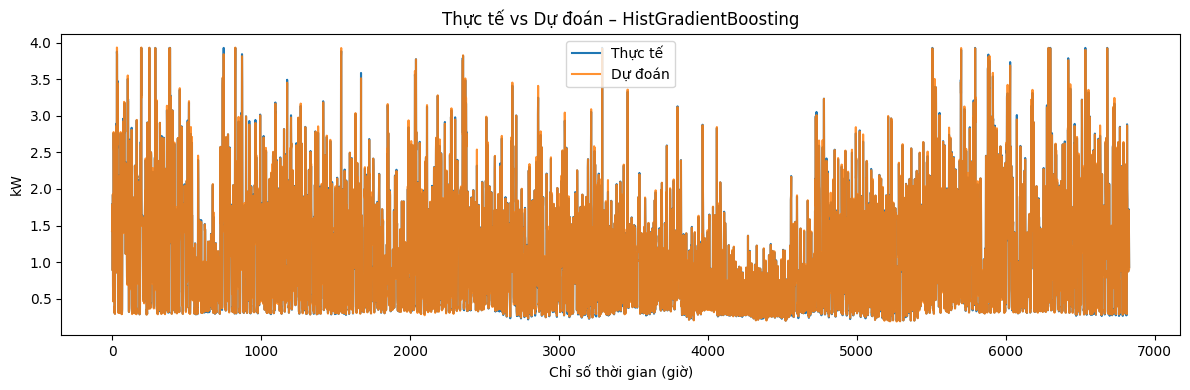

In [8]:
# ==== Cell 8: Đánh giá mô hình tốt nhất trên hold-out 20% ====
import matplotlib.pyplot as plt
best_name = max(results, key=lambda k: results[k][2])
print("Mô hình tốt nhất theo CV:", best_name)
best_model = models[best_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = r2_score(y_test, y_pred)
print(f"Test: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Thực tế")
plt.plot(y_pred, label="Dự đoán", alpha=0.85)
plt.title(f"Thực tế vs Dự đoán – {best_name}")
plt.xlabel("Chỉ số thời gian (giờ)"); plt.ylabel("kW")
plt.legend(); plt.tight_layout(); plt.show()


In [9]:
# ==== Cell 8.1 (phiên bản bảng): So sánh Thực tế vs Dự đoán ====
import pandas as pd
import numpy as np

# Tạo DataFrame so sánh
compare_df = pd.DataFrame({
    "Thực tế (kW)": y_test.values,
    "Dự đoán (kW)": y_pred
})

# Thêm cột sai số tuyệt đối & phần trăm sai số
compare_df["Sai số tuyệt đối"] = np.abs(compare_df["Thực tế (kW)"] - compare_df["Dự đoán (kW)"])
compare_df["Sai số (%)"] = 100 * compare_df["Sai số tuyệt đối"] / (compare_df["Thực tế (kW)"] + 1e-6)

# Hiển thị 20 mẫu cuối (phần mới nhất)
print("=== 20 giá trị gần nhất (thực tế vs dự đoán) ===")
display(compare_df.tail(20))

# Thống kê tổng quan
print("\n=== Thống kê sai số tổng quan ===")
print(compare_df[["Sai số tuyệt đối", "Sai số (%)"]].describe().round(3))


=== 20 giá trị gần nhất (thực tế vs dự đoán) ===


,Thực tế (kW),Dự đoán (kW),Sai số tuyệt đối,Sai số (%)
6809,0.273433,0.295698,0.022265,8.142656
6810,0.298367,0.304671,0.006304,2.112878
6811,0.314033,0.323599,0.009566,3.046204
6812,0.282567,0.291878,0.009311,3.295227
6813,1.008767,1.010647,0.001880,0.186371
6814,2.883933,2.868404,0.015529,0.538460
6815,1.999300,2.002616,0.003316,0.165870
6816,1.849967,1.854760,0.004793,0.259103
6817,1.352767,1.358358,0.005591,0.413334
6818,1.338900,1.336294,0.002606,0.194666



=== Thống kê sai số tổng quan ===
       Sai số tuyệt đối  Sai số (%)
count          6829.000    6829.000
mean              0.011       1.455
std               0.015       1.709
min               0.000       0.000
25%               0.003       0.387
50%               0.007       0.896
75%               0.013       1.938
max               0.240      21.099


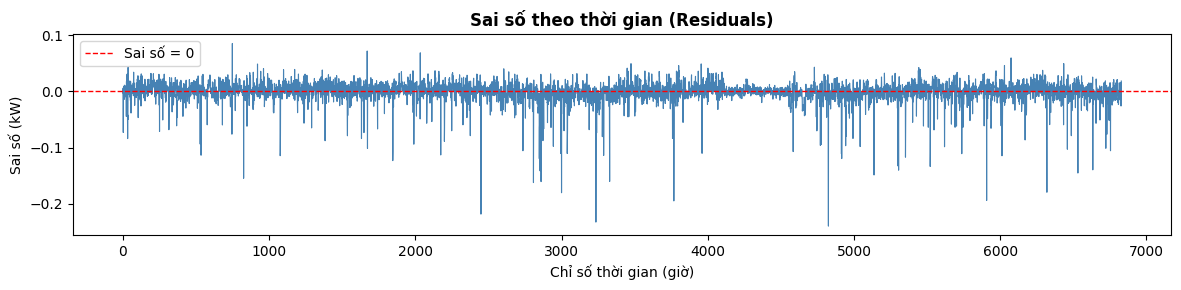

=== Thống kê sai số (Residuals – Test set) ===
Trung bình: -0.0008 kW
Độ lệch chuẩn: 0.0187 kW
Min: -0.2403 | Max: 0.0857


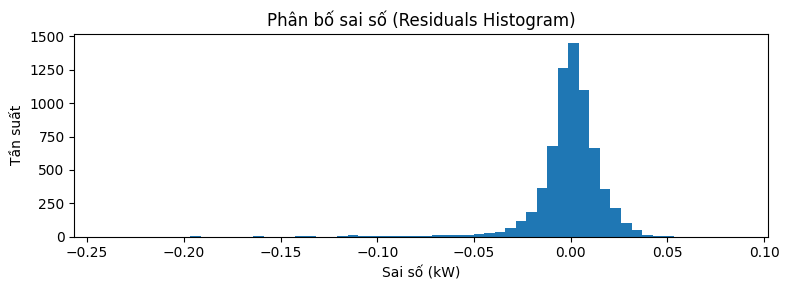

In [10]:
# ==== Cell 9: Phân tích sai số (Residuals) + Đặc trưng quan trọng ====
import numpy as np
import matplotlib.pyplot as plt

# Lấy dự đoán TEST an toàn: ưu tiên y_pred_test; nếu chưa có thì tính lại
try:
    y_pred_test
except NameError:
    y_pred_test = best_model.predict(X_test)

# --- 1) Phân tích sai số trên TẬP TEST ---
resid = y_test.values - y_pred_test

plt.figure(figsize=(12,3))
plt.plot(resid, color="steelblue", linewidth=0.8)
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="Sai số = 0")
plt.title("Sai số theo thời gian (Residuals)", fontsize=12, fontweight="bold")
plt.xlabel("Chỉ số thời gian (giờ)")
plt.ylabel("Sai số (kW)")
plt.legend()
plt.tight_layout()
plt.show()

# Thống kê mô tả sai số
print("=== Thống kê sai số (Residuals – Test set) ===")
print(f"Trung bình: {resid.mean():.4f} kW")
print(f"Độ lệch chuẩn: {resid.std():.4f} kW")
print(f"Min: {resid.min():.4f} | Max: {resid.max():.4f}")

# (Tuỳ chọn) Histogram phân bố sai số
plt.figure(figsize=(8,3))
plt.hist(resid, bins=60)
plt.title("Phân bố sai số (Residuals Histogram)")
plt.xlabel("Sai số (kW)")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

# --- 2) Biểu đồ tầm quan trọng của đặc trưng ---
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    names = X.columns
    order = np.argsort(importances)[::-1][:20]  # Top 20

    plt.figure(figsize=(12,5))
    plt.bar(range(len(order)), importances[order], alpha=0.85)
    plt.xticks(range(len(order)), [names[i] for i in order], rotation=45, ha="right")
    plt.title("Top 20 đặc trưng quan trọng (Feature Importance)", fontsize=12, fontweight="bold")
    plt.xlabel("Tên đặc trưng")
    plt.ylabel("Độ quan trọng (tỉ trọng)")
    plt.tight_layout()
    plt.show()

    print("\n=== Top 10 đặc trưng quan trọng ===")
    for i in order[:10]:
        print(f"{names[i]:25s}  |  Importance = {importances[i]:.4f}")



In [11]:
# ==== Cell 11: Chuẩn bị dữ liệu chuỗi cho LSTM (dự báo Global_active_power) ====
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Lấy chuỗi theo thời gian: Global_active_power (kW)
series = clean[["Datetime", "Global_active_power"]].copy()
series = series.sort_values("Datetime").set_index("Datetime")

values = series["Global_active_power"].values.reshape(-1, 1)

# Chuẩn hóa về [0, 1] cho LSTM
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# Hàm tạo các cửa sổ trượt (window) cho bài toán dự báo
def create_sequences(data, window=24):
    """
    data: mảng 2D (n, 1) sau khi scale
    window: số giờ dùng để dự báo giờ tiếp theo
    """
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 24  # dùng 24 giờ trước để dự báo giờ tiếp theo
X_seq, y_seq = create_sequences(values_scaled, window=WINDOW)

# Chia train/test theo thời gian (80/20)
split = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

# Reshape về dạng (samples, timesteps, features) cho LSTM
X_train_lstm = X_train_lstm[..., np.newaxis]
X_test_lstm  = X_test_lstm[..., np.newaxis]

print("Kích thước X_train_lstm:", X_train_lstm.shape)
print("Kích thước X_test_lstm :", X_test_lstm.shape)
print("Số mẫu train/test:", len(X_train_lstm), len(X_test_lstm))


Kích thước X_train_lstm: (27315, 24, 1)
Kích thước X_test_lstm : (6829, 24, 1)
Số mẫu train/test: 27315 6829


In [12]:
# ==== Cell 12: Mạng nơ-ron (MLP) dự báo chuỗi thời gian – thay cho LSTM, không cần tensorflow ====
from sklearn.neural_network import MLPRegressor

# Dẹp (flatten) chuỗi 24 giờ thành 1 vector có WINDOW phần tử
X_train_flat = X_train_lstm.reshape(len(X_train_lstm), WINDOW)
X_test_flat  = X_test_lstm.reshape(len(X_test_lstm), WINDOW)

model_lstm = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # 2 hidden layer: 64 và 32 neuron
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    max_iter=200,
    random_state=42,
    early_stopping=True,           # dừng sớm nếu không cải thiện
    n_iter_no_change=10,
    validation_fraction=0.2
)

model_lstm.fit(X_train_flat, y_train_lstm)

print("Train R² score:", model_lstm.score(X_train_flat, y_train_lstm))
print("Đã huấn luyện xong mạng nơ-ron MLP (thay cho LSTM, không dùng tensorflow).")


Train R² score: 0.6139829158782959
Đã huấn luyện xong mạng nơ-ron MLP (thay cho LSTM, không dùng tensorflow).


MLP (thay LSTM) – RMSE: 0.5050 kW | MAE: 0.3600 kW | R²: 0.5332

Không tính được metrics cho mô hình truyền thống (best_model). Chi tiết: got an unexpected keyword argument 'squared'


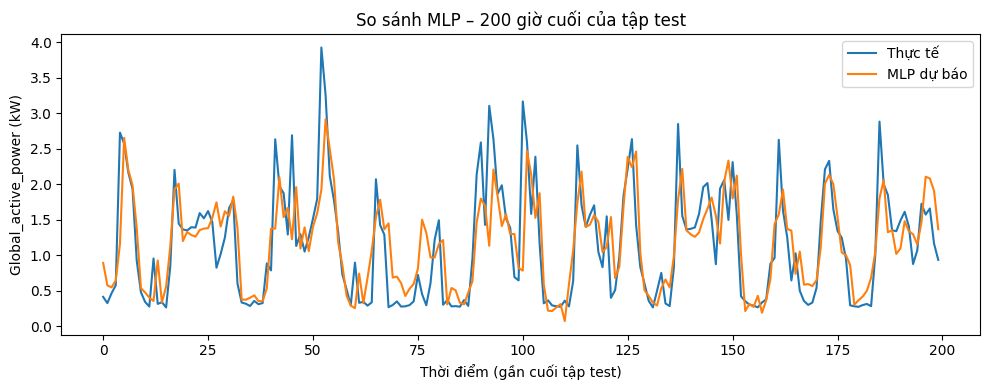

In [13]:
# ==== Cell 13: Đánh giá mạng nơ-ron (MLP) & so sánh với mô hình truyền thống ====
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Dự báo trên tập test (giá trị đã scale)
X_test_flat = X_test_lstm.reshape(len(X_test_lstm), WINDOW)
y_pred_lstm_scaled = model_lstm.predict(X_test_flat).reshape(-1, 1)

# Đưa về đơn vị kW (inverse transform)
y_test_inv = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).ravel()
y_pred_inv = scaler.inverse_transform(y_pred_lstm_scaled).ravel()

# Tính các chỉ số đánh giá
rmse_lstm = mean_squared_error(y_test_inv, y_pred_inv) ** 0.5

mae_lstm  = mean_absolute_error(y_test_inv, y_pred_inv)
r2_lstm   = r2_score(y_test_inv, y_pred_inv)

print(f"MLP (thay LSTM) – RMSE: {rmse_lstm:.4f} kW | MAE: {mae_lstm:.4f} kW | R²: {r2_lstm:.4f}")

# So sánh nhanh với mô hình truyền thống tốt nhất (nếu đã có best_model và y_pred_test)
try:
    rmse_best = mean_squared_error(y_test, y_pred_test, squared=False)
    mae_best  = mean_absolute_error(y_test, y_pred_test)
    r2_best   = r2_score(y_test, y_pred_test)
    
    print("\n=== So sánh với mô hình truyền thống tốt nhất (best_model) ===")
    print(f"Best model – RMSE: {rmse_best:.4f} kW | MAE: {mae_best:.4f} kW | R²: {r2_best:.4f}")
except Exception as e:
    print("\nKhông tính được metrics cho mô hình truyền thống (best_model). Chi tiết:", e)

# Vẽ 200 điểm cuối cùng của tập test: Thực tế vs MLP dự báo
N = 200
plt.figure(figsize=(10,4))
plt.plot(y_test_inv[-N:], label="Thực tế", linewidth=1.5)
plt.plot(y_pred_inv[-N:], label="MLP dự báo", linewidth=1.5)
plt.title(f"So sánh MLP – {N} giờ cuối của tập test")
plt.xlabel("Thời điểm (gần cuối tập test)")
plt.ylabel("Global_active_power (kW)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# ==== Cell tổng hợp: So sánh mô hình tốt nhất (best_model) và MLP ====
import pandas as pd
import numpy as np

summary_df = pd.DataFrame([
    {
        "Mô hình": f"Best model ({best_name})",
        "MAE (kW)": mae,
        "RMSE (kW)": rmse,
        "R²": r2,
    },
    {
        "Mô hình": "MLP cho chuỗi thời gian",
        "MAE (kW)": mae_lstm,
        "RMSE (kW)": rmse_lstm,
        "R²": r2_lstm,
    }
])

print("=== So sánh tổng quan các mô hình ===")
display(summary_df)


=== So sánh tổng quan các mô hình ===


,Mô hình,MAE (kW),RMSE (kW),R²
0,Best model (HistGradientBoosting),0.010969,0.018738,0.999357
1,MLP cho chuỗi thời gian,0.359976,0.505028,0.533246


In [15]:
# ==== Cell cuối: DỰ ĐOÁN lượng tiêu thụ điện trên tập test ====
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Dùng mô hình tốt nhất để dự đoán trên tập test
y_pred = best_model.predict(X_test)

# 2) Gộp vào bảng so sánh (đây chính là phần "dự đoán" trong đề bài)
du_doan_df = pd.DataFrame({
    "Datetime": df_fe["Datetime"].iloc[split:],   # split đã tạo ở Cell 5
    "Thực tế (kW)": y_test.values,
    "Dự đoán (kW)": y_pred
})

print("=== 24 giá trị gần nhất: Thực tế vs Dự đoán ===")
display(du_doan_df.tail(24))

# 3) Tính lại các chỉ số đánh giá cho rõ ràng
mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = r2_score(y_test, y_pred)

print("\n=== KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST ===")
print(f"MAE  = {mae:.4f} kW")
print(f"RMSE = {rmse:.4f} kW")
print(f"R²   = {r2:.4f}")


=== 24 giá trị gần nhất: Thực tế vs Dự đoán ===


,Datetime,Thực tế (kW),Dự đoán (kW)
34120,2010-11-25 22:00:00,1.247567,1.250738
34121,2010-11-25 23:00:00,0.957000,0.977069
34122,2010-11-26 00:00:00,0.294300,0.306980
34123,2010-11-26 01:00:00,0.281000,0.304258
34124,2010-11-26 02:00:00,0.273433,0.295698
34125,2010-11-26 03:00:00,0.298367,0.304671
34126,2010-11-26 04:00:00,0.314033,0.323599
34127,2010-11-26 05:00:00,0.282567,0.291878
34128,2010-11-26 06:00:00,1.008767,1.010647
34129,2010-11-26 07:00:00,2.883933,2.868404



=== KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST ===
MAE  = 0.0110 kW
RMSE = 0.0187 kW
R²   = 0.9994
